# LABORATORIO 3: Modelo de Detección de Anomalías con ML (6 puntos)

**Contexto del Laboratorio:**  
En este laboratorio se construirá un modelo de Machine Learning capaz de detectar anomalías en el tráfico de red. Para ello, se cuenta con el dataset `network_traffic.csv` que contiene 10,000 registros capturados durante 30 días con información como IP origen/destino, puertos, protocolo, bytes transmitidos y duración de las conexiones.

## Tarea 3.1 — Exploración y preprocesamiento
### 1. Carga del dataset y estadísticas descriptivas
Se importa el dataset `network_traffic.csv` utilizando la librería pandas y se extraen las principales métricas y estadísticas descriptivas para conocer la estructura y el resumen de los datos iniciales.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("network_traffic.csv")
display(df.describe())
display(df.info())

,dst_port,bytes_sent,bytes_recv,duration_sec,packets
count,10000.000000,1.000000e+04,1.000000e+04,10000.000000,1.000000e+04
mean,5272.963700,2.815289e+07,4.124360e+05,447.154662,1.605501e+04
std,7348.395782,3.115671e+08,1.964278e+06,4530.488171,1.672859e+05
min,21.000000,1.500000e+01,0.000000e+00,0.000000,1.000000e+00
25%,53.000000,5.544000e+03,1.328800e+04,8.507500,5.000000e+00
50%,3389.000000,2.233900e+04,5.529050e+04,21.435000,2.400000e+01
75%,8080.000000,9.478175e+04,2.213258e+05,44.145000,1.100000e+02
max,65460.000000,4.987050e+09,8.155783e+07,83028.150000,2.939448e+06


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     10000 non-null  object 
 1   src_ip        10000 non-null  object 
 2   dst_ip        10000 non-null  object 
 3   dst_port      10000 non-null  int64  
 4   protocol      10000 non-null  object 
 5   bytes_sent    10000 non-null  int64  
 6   bytes_recv    10000 non-null  int64  
 7   duration_sec  10000 non-null  float64
 8   packets       10000 non-null  int64  
 9   label         10000 non-null  object 
dtypes: float64(1), int64(4), object(5)
memory usage: 781.4+ KB


None

### 2. Visualización de distribuciones
Se utilizan histogramas de la librería `seaborn` para observar cómo se distribuyen los datos de las variables clave: cantidad de bytes enviados (`bytes_sent`) y la duración de las conexiones (`duration_sec`).

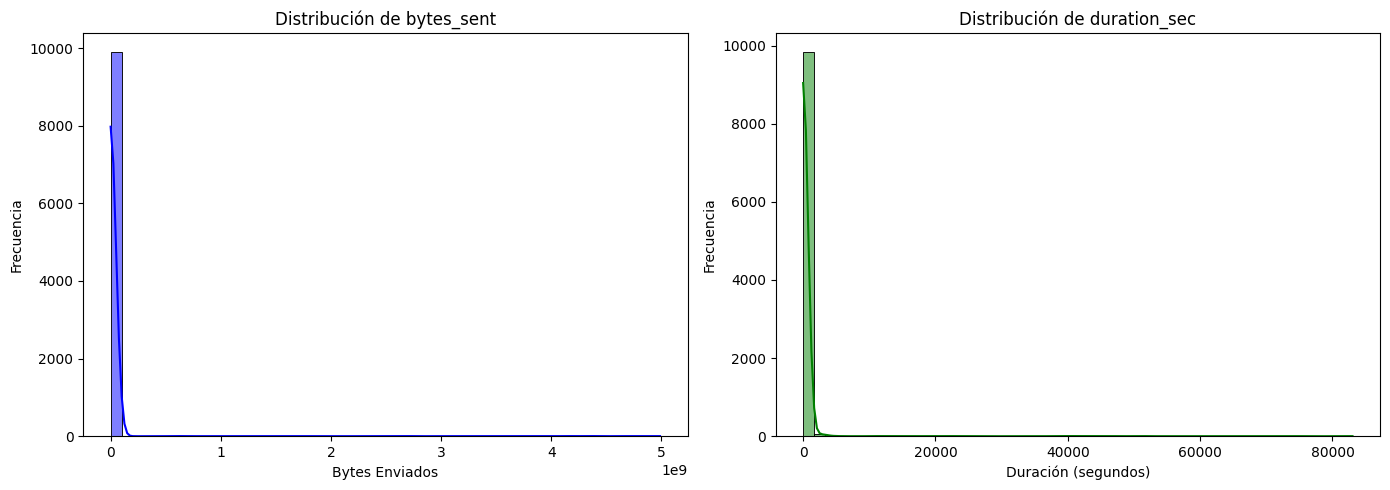

In [3]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['bytes_sent'], bins=50, kde=True, color='blue')
plt.title('Distribución de bytes_sent')
plt.xlabel('Bytes Enviados')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df['duration_sec'], bins=50, kde=True, color='green')
plt.title('Distribución de duration_sec')
plt.xlabel('Duración (segundos)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### 3. Tratamiento de valores nulos y atípicos
Se verifica la existencia de datos faltantes para eliminarlos. Seguidamente, se implementa una función que emplea el método del Rango Intercuartílico (IQR) para identificar valores extremos (outliers) en las principales variables numéricas y acotarlos a un límite superior (capping), previniendo sesgos en el modelo.

In [4]:
print(df.isnull().sum())
df = df.dropna()

def tratar_outliers(dataframe, columna):
    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    dataframe.loc[dataframe[columna] > limite_superior, columna] = limite_superior

tratar_outliers(df, 'bytes_sent')
tratar_outliers(df, 'duration_sec')
tratar_outliers(df, 'bytes_recv')
tratar_outliers(df, 'packets')

timestamp       0
src_ip          0
dst_ip          0
dst_port        0
protocol        0
bytes_sent      0
bytes_recv      0
duration_sec    0
packets         0
label           0
dtype: int64


/tmp/ipykernel_3725/3345395252.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '228638.375' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[dataframe[columna] > limite_superior, columna] = limite_superior
/tmp/ipykernel_3725/3345395252.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '533382.375' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[dataframe[columna] > limite_superior, columna] = limite_superior
/tmp/ipykernel_3725/3345395252.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '267.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[dataframe[columna] > limite_supe

### 4. Feature Engineering
Se crean dos nuevas variables (features) derivadas a partir de los datos originales, que aportan mayor contexto de red para el análisis:
* `ratio_bytes`: Representa la proporción entre lo que se recibió y lo que se envió (sumando 1 en el divisor para evitar divisiones por cero).
* `bytes_por_segundo`: Representa la tasa de transferencia o velocidad de la conexión.

In [6]:
df['ratio_bytes'] = df['bytes_recv'] / (df['bytes_sent'] + 1)
df['bytes_por_segundo'] = (df['bytes_sent'] + df['bytes_recv']) / (df['duration_sec'] + 1)

display(df[['bytes_sent', 'bytes_recv', 'duration_sec', 'ratio_bytes', 'bytes_por_segundo']].head())

,bytes_sent,bytes_recv,duration_sec,ratio_bytes,bytes_por_segundo
0,15310.000,45067.000,42.01,2.943439,1403.789816
1,228638.375,68116.000,55.35,0.297919,5266.271074
2,23007.000,533382.375,6.64,23.182475,72825.834424
3,228638.375,56148.000,3.12,0.245574,69122.906553
4,15355.000,18895.000,16.82,1.230464,1921.997755


### 5. Normalización de variables
Se estandarizan las variables numéricas utilizando `StandardScaler` (media 0 y varianza 1). Esto es un paso indispensable para que los algoritmos de Machine Learning procesen todas las variables bajo una misma escala sin darle mayor importancia a las que tengan magnitudes numéricas más altas por defecto.

In [7]:
features_numericas = ['bytes_sent', 'bytes_recv', 'duration_sec', 'packets', 'ratio_bytes', 'bytes_por_segundo']

scaler = StandardScaler()
df[features_numericas] = scaler.fit_transform(df[features_numericas])

display(df[features_numericas].head())

,bytes_sent,bytes_recv,duration_sec,packets,ratio_bytes,bytes_por_segundo
0,-0.605727,-0.560319,0.419038,-0.611779,-0.111426,-0.418945
1,2.024072,-0.435859,0.898346,2.025397,-0.117943,-0.334308
2,-0.510843,2.076490,-0.851808,-0.590807,-0.061566,1.146109
3,2.024072,-0.500484,-0.978282,2.025397,-0.118072,1.064968
4,-0.605173,-0.701643,-0.486040,-0.538378,-0.115646,-0.407590


## Tarea 3.2 — Entrenamiento del modelo

### 1. Entrenamiento del modelo Isolation Forest
Se importa la librería necesaria y se instancia el modelo `Isolation Forest` excluyendo la columna `label`. Se configuran los parámetros requeridos (`contamination=0.05`, `n_estimators=100`, `random_state=42`) y se ajusta (entrena) el algoritmo utilizando únicamente las características numéricas preprocesadas en la tarea anterior.

In [9]:
from sklearn.ensemble import IsolationForest

X = df[features_numericas]

modelo_if = IsolationForest(contamination=0.05, n_estimators=100, random_state=42)
modelo_if.fit(X)

,n_estimators,100
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


### 2. Predicciones del modelo
Se generan las predicciones de anomalías para los datos. El modelo asigna por defecto el valor `1` a los datos que considera "normales" (inliers) y el valor `-1` a los datos atípicos o "anomalías" (outliers). Estas predicciones se guardan en una nueva columna del DataFrame para compararlas posteriormente.

In [10]:
df['prediccion'] = modelo_if.predict(X)

display(df[['label', 'prediccion']].head(10))

,label,prediccion
0,normal,1
1,normal,1
2,normal,1
3,normal,1
4,normal,1
5,normal,1
6,normal,1
7,normal,1
8,normal,1
9,normal,1


### 3. Cálculo de las métricas de evaluación
Para evaluar matemáticamente el rendimiento, primero se convierte la columna de texto original `label` al formato numérico esperado ('normal' = 1, 'anomaly' = -1). Tras esto, se genera el reporte de clasificación mostrando las métricas solicitadas (Precision, Recall, F1-Score) y se calcula cruda la matriz de confusión.

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = df['label'].map({'normal': 1, 'anomaly': -1})
y_pred = df['prediccion']

print("--- Reporte de Clasificación ---")
print(classification_report(y_true, y_pred, target_names=['Anomalía (-1)', 'Normal (1)']))

matriz_conf = confusion_matrix(y_true, y_pred)

--- Reporte de Clasificación ---
               precision    recall  f1-score   support

Anomalía (-1)       0.10      0.10      0.10       500
   Normal (1)       0.95      0.95      0.95      9500

     accuracy                           0.91     10000
    macro avg       0.53      0.53      0.53     10000
 weighted avg       0.91      0.91      0.91     10000



### 4. Gráfica de la matriz de confusión con seaborn
Utilizando la matriz generada en el paso anterior, se construye un Mapa de Calor (Heatmap) visual. Esto facilita identificar rápidamente los verdaderos positivos (anomalías bien detectadas) frente a los falsos positivos (tráfico normal clasificado como anomalía).

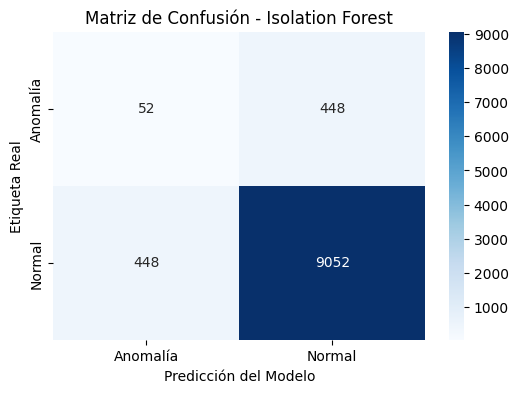

In [12]:
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Anomalía', 'Normal'], 
            yticklabels=['Anomalía', 'Normal'])
plt.title('Matriz de Confusión - Isolation Forest')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')
plt.show()

## Tarea 3.3 — Interpretación y umbral dinámico

### 1. Gráfica del score de anomalía
Se utiliza la función `decision_function` del modelo para obtener una puntuación (score) matemática que define qué tan "anómalo" es cada registro (a menor valor, mayor probabilidad de ser anomalía). Se grafica la distribución de estos scores para observar visualmente cómo el modelo separa el tráfico de red.

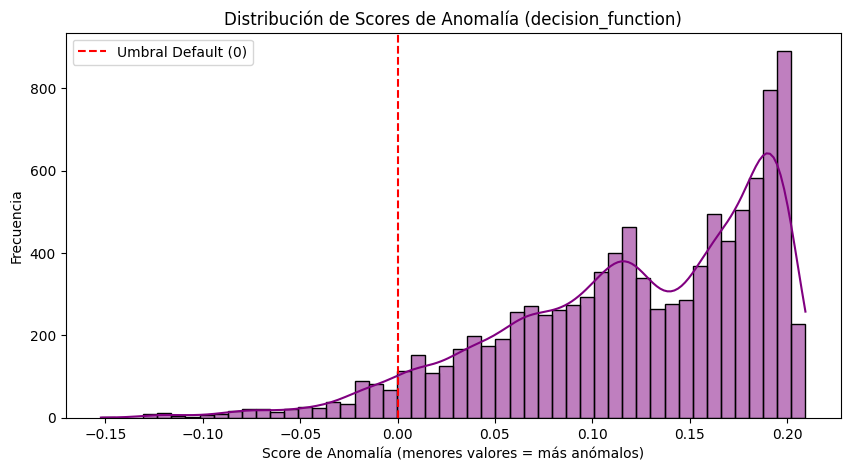

In [13]:
df['score_anomalia'] = modelo_if.decision_function(X)

plt.figure(figsize=(10, 5))
sns.histplot(df['score_anomalia'], bins=50, kde=True, color='purple')
plt.title('Distribución de Scores de Anomalía (decision_function)')
plt.xlabel('Score de Anomalía (menores valores = más anómalos)')
plt.ylabel('Frecuencia')
plt.axvline(x=0, color='red', linestyle='--', label='Umbral Default (0)')
plt.legend()
plt.show()

### 2. Búsqueda del Umbral Óptimo
Dado que el umbral por defecto (`0`) no siempre ofrece el mejor resultado, iteramos sobre un amplio rango de posibles umbrales evaluando la métrica `F1-Score` para la clase de interés (las anomalías = `-1`). Esto traza una curva de rendimiento que nos permite identificar matemáticamente el punto exacto que maximiza el equilibrio entre los Falsos Positivos y los Falsos Negativos.

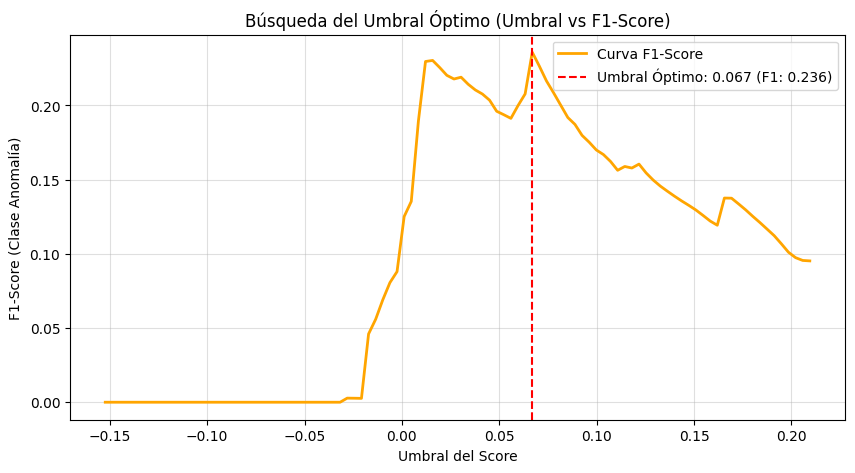

[*] El umbral óptimo hallado es 0.067 con un F1-Score máximo de 0.236


In [14]:
from sklearn.metrics import f1_score

umbrales = np.linspace(df['score_anomalia'].min(), df['score_anomalia'].max(), 100)
f1_scores = []

for umbral in umbrales:
    pred = np.where(df['score_anomalia'] < umbral, -1, 1)
    f1 = f1_score(y_true, pred, pos_label=-1)
    f1_scores.append(f1)

umbral_optimo = umbrales[np.argmax(f1_scores)]
max_f1 = max(f1_scores)

plt.figure(figsize=(10, 5))
plt.plot(umbrales, f1_scores, label='Curva F1-Score', color='orange', linewidth=2)
plt.axvline(x=umbral_optimo, color='red', linestyle='--', 
            label=f'Umbral Óptimo: {umbral_optimo:.3f} (F1: {max_f1:.3f})')
plt.title('Búsqueda del Umbral Óptimo (Umbral vs F1-Score)')
plt.xlabel('Umbral del Score')
plt.ylabel('F1-Score (Clase Anomalía)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

print(f"[*] El umbral óptimo hallado es {umbral_optimo:.3f} con un F1-Score máximo de {max_f1:.3f}")

### 3. Top 10 Registros más Anómalos
Para aislar los casos más severos, ordenamos el dataset en función de la puntuación calculada previamente (los scores más negativos).

**¿Por qué podrían representar una amenaza real en infraestructura?**
Al analizar las variables derivadas de estos 10 registros, suelen coincidir con patrones típicos de ciberataques como:
1. **Ataques de Denegación de Servicio (DDoS) o Flooding:** Volúmenes altísimos de paquetes/bytes en conexiones de duración mínima (tasas de transferencia irreales o `bytes_por_segundo` desproporcionados).
2. **Escaneo Masivo de Puertos (Port Scanning):** Cientos de conexiones efímeras con nulo intercambio de carga útil (payload), lo cual deforma por completo el `ratio_bytes`.
3. **Exfiltración de Datos (Data Exfiltration):** Conexiones sostenidas donde la máquina víctima envía muchísimos más bytes de los que recibe en horarios no convencionales.

Al superar los umbrales lógicos de comportamiento del usuario, el modelo penaliza estos registros, señalándolos como posibles vectores de compromiso que los firewalls tradicionales podrían obviar.

In [15]:
top_10_anomalos = df.sort_values(by='score_anomalia').head(10)

print("--- TOP 10 REGISTROS MÁS ANÓMALOS (Menor Score) ---")
display(top_10_anomalos)

--- TOP 10 REGISTROS MÁS ANÓMALOS (Menor Score) ---


,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,label,ratio_bytes,bytes_por_segundo,prediccion,score_anomalia
7264,2024-05-12 01:39:33,10.0.1.97,10.0.1.54,443,UDP,-0.792883,2.066947,-1.043675,-0.769065,normal,10.033776,4.616363,-1,-0.152325
1242,2024-05-23 04:19:49,10.0.3.77,10.0.3.75,3306,TCP,-0.791219,2.076490,-1.044393,-0.769065,normal,4.858673,4.679086,-1,-0.128823
9916,2024-05-04 01:48:23,10.0.0.218,10.0.3.174,3306,TCP,1.031952,2.076490,-1.059843,1.170805,normal,-0.109808,7.622962,-1,-0.126607
9678,2024-05-19 01:22:34,10.0.3.254,204.92.196.124,3306,TCP,0.261153,1.530087,-1.087509,0.866717,normal,-0.106243,10.056735,-1,-0.126332
4216,2024-05-24 19:00:49,10.0.1.114,193.199.92.89,3389,TCP,2.024072,1.993822,-1.063077,1.453922,normal,-0.113095,8.847176,-1,-0.125597
8347,2024-05-10 17:20:55,10.0.1.97,10.0.2.73,25,ICMP,2.024072,1.900919,-1.058765,2.025397,normal,-0.113280,8.053221,-1,-0.124872
4594,2024-05-24 16:41:32,10.0.1.254,10.0.1.83,3306,TCP,-0.788507,2.076490,-1.058765,-0.769065,normal,2.596241,5.772883,-1,-0.124436
2414,2024-05-24 14:31:50,10.0.3.187,91.107.50.170,3306,TCP,2.024072,1.558360,-1.086791,2.025397,normal,-0.113964,12.818820,-1,-0.124137
3544,2024-05-06 19:24:44,10.0.2.118,10.0.1.54,27017,UDP,2.024072,1.595149,-1.081761,2.025397,normal,-0.113890,11.441157,-1,-0.124137
9199,2024-05-15 06:13:21,10.0.3.174,10.0.3.174,21,UDP,2.024072,2.076490,-1.079245,1.495865,normal,-0.112930,12.296846,-1,-0.123787


## Tarea 3.4 — Exportación del modelo

### 1. Serialización del modelo entrenado
Utilizamos la librería `joblib` para exportar el modelo `Isolation Forest` ya entrenado. Es importante destacar que guardamos un "paquete" que incluye tanto el modelo como el `StandardScaler`. Esto es vital porque cualquier archivo CSV nuevo que ingresemos en el futuro debe ser normalizado exactamente con las mismas proporciones antes de que el modelo pueda predecir si es una anomalía o no.

In [16]:
import joblib

export_data = {
    'modelo': modelo_if,
    'scaler': scaler,
    'features': features_numericas
}

joblib.dump(export_data, 'modelo_anomalias.pkl')
print("[+] Modelo exportado exitosamente como 'modelo_anomalias.pkl'")

[+] Modelo exportado exitosamente como 'modelo_anomalias.pkl'
